# TI3145TU Final Assignment 
## Health Insurance 

We hope you enjoy this assignment, good luck!

Student names: XXX

Student numbers: XXX

### Imports

In [2]:
import numpy as np
import pandas as pd

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

import matplotlib.pyplot as plt

### Load data

In [3]:
# These are your training samples along with their labels
data = pd.read_csv('health_insurance_train.csv')
data.head()

# You need to extract the features and the regression target. The regression target is 'whrswk'. 

,whrswk,hhi,whi,hhi2,education,race,hispanic,experience,kidslt6,kids618,husby,region
0,40.0,no,yes,yes,13-15years,white,no,17.0,0.0,1.0,22.000,south
1,40.0,no,yes,yes,13-15years,white,no,4.0,1.0,0.0,15.000,south
2,0.0,yes,no,yes,16years,white,no,21.0,0.0,1.0,99.999,other
3,40.0,no,no,yes,13-15years,white,no,22.0,NaN,NaN,60.000,northcentral
4,35.0,no,yes,no,12years,white,no,15.0,0.0,2.0,0.000,south


### Pipeline 1

In [4]:
import numpy as np
import pandas as pd
import sklearn

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt

# These are your training samples along with their labels
data = pd.read_csv('health_insurance_train.csv')
# Here we separate target (y) and features (X)
X = data.drop('whrswk', axis=1)
y = data['whrswk']
# divide columns into numerical and non-numerical features
#numerical_feats = ['experience', 'kidslt6', 'kids618', 'husby']
#categorical_feats = ['hhi', 'whi', 'hhi2', 'education', 'race', 'hispanic', 'region']
# transformer for numbers
#numerical_transf = Pipeline(steps=[('imputer', SimpleImputer(strategy="median")), ('scaler', StandardScaler())])
# transformer for non-numbers
#categorical_transf = Pipeline(steps=[('imputer', SimpleImputer(strategy="most_frequent")), ('encoder', OneHotEncoder())])
#
#preprocessor = ColumnTransformer(
#    transformers=[
#        ('num', numerical_transf, numerical_feats),
#        ('cat', categorical_transf, categorical_feats)
#    ]
#)

#preprocessor.fit(X)

#X_transformed = preprocessor.transform(X)

#print(X_transformed[0])
# You need to extract the features and the regression target. The regression target is 'whrswk'.


# ---------------------
# Pipeline 1: Simple baseline pipeline
# ---------------------
numerical_feats_1 = ['experience', 'kidslt6', 'kids618', 'husby']
categorical_feats_1 = ['hhi', 'whi', 'hhi2', 'education', 'race', 'hispanic', 'region']

numerical_transf_1 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transf_1 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor1 = ColumnTransformer([
    ('num', numerical_transf_1, numerical_feats_1),
    ('cat', categorical_transf_1, categorical_feats_1)
])

# ---------------------
# Pipeline 2: Engineered + scaled pipeline
# ---------------------
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor

# Separate numerical features — we'll split them into two groups
poly_feat = ['experience']
other_num_feats = ['kidslt6', 'kids618', 'husby']
cat_feats = ['hhi', 'whi', 'hhi2', 'education', 'race', 'hispanic', 'region']

# Transformer for the polynomial 'experience' feature
poly_transf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# Transformer for other numeric features (no polynomial)
other_num_transf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Transformer for categorical features
cat_transf = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine all transformations
preprocessor2 = ColumnTransformer([
    ('poly', poly_transf, poly_feat),
    ('num', other_num_transf, other_num_feats),
    ('cat', cat_transf, cat_feats)
])



### Dummy regressor

In [5]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error

dummy = DummyRegressor(strategy="mean")
dummy.fit(X, y)
y_pred = dummy.predict(X)
mae_baseline = mean_absolute_error(y, y_pred)
print("Baseline MAE (DummyRegressor, mean strategy):", mae_baseline)

Baseline MAE (DummyRegressor, mean strategy): 16.97666512


### Model training

In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error


models = {
    "KNN": KNeighborsRegressor(),
    "SGD": SGDRegressor(random_state=42),  # add random_state for reproducibility
    "RandomForest": RandomForestRegressor(random_state=42),
    "DecisionTree": DecisionTreeRegressor(random_state=42)
}
results = {}

# Loop over models
for name, model in models.items():
    # Create full pipeline: preprocessing + model
    full_pipeline = Pipeline([('preprocessor', preprocessor2),  ('regressor', model)])
    #full_pipeline = make_pipeline2_simple(model)
    # Cross-validated MAE (5-fold CV)
    cv_scores = cross_val_score(full_pipeline, X, y, cv=5, scoring='neg_mean_absolute_error')
    
    # Convert negative MAE to positive
    mae = -cv_scores.mean()
    
    results[name] = mae
    print(name, results[name])

    


KNN 12.256519999999998
SGD 11.980481541984751
RandomForest 11.8080129018426
DecisionTree 14.157187619047619


### Tuning


🔍 Nested CV for KNN
  🔸 Fold MAE: 11.9392 | Best params: {'regressor__n_neighbors': 13, 'regressor__p': 1, 'regressor__weights': 'uniform'}
  🔸 Fold MAE: 11.4743 | Best params: {'regressor__n_neighbors': 13, 'regressor__p': 1, 'regressor__weights': 'uniform'}
  🔸 Fold MAE: 12.5781 | Best params: {'regressor__n_neighbors': 16, 'regressor__p': 1, 'regressor__weights': 'distance'}
  🔸 Fold MAE: 11.8326 | Best params: {'regressor__n_neighbors': 14, 'regressor__p': 1, 'regressor__weights': 'uniform'}
  🔸 Fold MAE: 11.6419 | Best params: {'regressor__n_neighbors': 15, 'regressor__p': 1, 'regressor__weights': 'uniform'}

✅ Nested CV Result for KNN: 11.8932 ± 0.3778

🔍 Nested CV for SGD
  🔸 Fold MAE: 12.0096 | Best params: {'regressor__alpha': 5e-05, 'regressor__eta0': 0.001, 'regressor__l1_ratio': 0.9, 'regressor__learning_rate': 'optimal', 'regressor__loss': 'huber', 'regressor__max_iter': 2000, 'regressor__penalty': 'elasticnet', 'regressor__tol': 0.0001}
  🔸 Fold MAE: 11.2575 | Best param

/usr/local/lib/python3.10/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


  🔸 Fold MAE: 10.9115 | Best params: {'regressor__criterion': 'absolute_error', 'regressor__max_depth': 5, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 2}
  🔸 Fold MAE: 10.6150 | Best params: {'regressor__criterion': 'absolute_error', 'regressor__max_depth': 5, 'regressor__min_samples_leaf': 5, 'regressor__min_samples_split': 2}
  🔸 Fold MAE: 11.3610 | Best params: {'regressor__criterion': 'absolute_error', 'regressor__max_depth': 5, 'regressor__min_samples_leaf': 10, 'regressor__min_samples_split': 2}
  🔸 Fold MAE: 10.5240 | Best params: {'regressor__criterion': 'absolute_error', 'regressor__max_depth': 5, 'regressor__min_samples_leaf': 10, 'regressor__min_samples_split': 2}
  🔸 Fold MAE: 10.6460 | Best params: {'regressor__criterion': 'absolute_error', 'regressor__max_depth': 5, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 10}

✅ Nested CV Result for DecisionTree: 10.8115 ± 0.3035

🔍 Nested CV for RandomForest


/usr/local/lib/python3.10/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


  🔸 Fold MAE: 10.5633 | Best params: {'regressor__criterion': 'absolute_error', 'regressor__min_samples_leaf': 15, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}
  🔸 Fold MAE: 10.3562 | Best params: {'regressor__criterion': 'absolute_error', 'regressor__min_samples_leaf': 15, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}
  🔸 Fold MAE: 11.0631 | Best params: {'regressor__criterion': 'absolute_error', 'regressor__min_samples_leaf': 15, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}
  🔸 Fold MAE: 10.3837 | Best params: {'regressor__criterion': 'absolute_error', 'regressor__min_samples_leaf': 15, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}
  🔸 Fold MAE: 10.5533 | Best params: {'regressor__criterion': 'absolute_error', 'regressor__min_samples_leaf': 15, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}

✅ Nested CV Result for RandomForest: 10.5839 ± 0.2541

=== 🧾 Nested CV Summary ===


,Mean_MAE,Std_MAE
KNN,11.893217,0.377763
SGD,11.892428,0.393986
DecisionTree,10.811500,0.303516
RandomForest,10.583921,0.254125


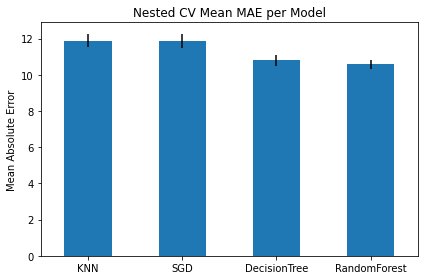

In [6]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

# Define outer and inner CV
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Define parameter grids
param_grids = {
    'KNN': {
        'regressor__n_neighbors': [13, 14, 15, 16, 17],
        'regressor__weights': ['uniform', 'distance'],
        'regressor__p': [1, 2]
    },
    'SGD': {
        'regressor__loss': ['squared_error', 'huber'],
        'regressor__penalty': ['l2', 'elasticnet'],
        'regressor__alpha': [5e-5, 8e-5, 1e-4],
        'regressor__l1_ratio': [0.1, 0.5, 0.9],   # only used if elasticnet
        'regressor__learning_rate': ['optimal', 'adaptive'],
        'regressor__eta0': [0.001, 0.01, 0.1],
        'regressor__max_iter': [2000, 5000],
        'regressor__tol': [1e-3, 1e-4]
    },
    'DecisionTree': {
        'regressor__max_depth': [5, 10, 15],
        'regressor__min_samples_split': [2, 5, 10],
        'regressor__min_samples_leaf': [2, 5, 10],
        'regressor__criterion': ['absolute_error'],
    },
    'RandomForest': {
        'regressor__n_estimators': [100, 200],
        'regressor__criterion': ['absolute_error'],
        'regressor__min_samples_split': [5, 10],
        'regressor__min_samples_leaf': [10, 15],
    }
}

# Models
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    "KNN": KNeighborsRegressor(),
    "SGD": SGDRegressor(random_state=42),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42)
}

# Store nested CV results
nested_results = {}

# Loop over models
for name, model in models.items():
    print(f"\n🔍 Nested CV for {name}")

    pipeline = Pipeline([
        ('preprocessor', preprocessor2),
        ('regressor', model)
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        scoring='neg_mean_absolute_error',
        cv=inner_cv,
        n_jobs=-1
    )

    outer_mae_scores = []

    # Manual outer CV
    for train_idx, test_idx in outer_cv.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Fit inner GridSearchCV
        grid_search.fit(X_train, y_train)

        # Evaluate best estimator on outer test fold
        best_model = grid_search.best_estimator_
        y_pred = best_model.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        outer_mae_scores.append(mae)

        print(f"  🔸 Fold MAE: {mae:.4f} | Best params: {grid_search.best_params_}")

    mean_mae = np.mean(outer_mae_scores)
    std_mae = np.std(outer_mae_scores)
    nested_results[name] = {'Mean_MAE': mean_mae, 'Std_MAE': std_mae}

    print(f"\n✅ Nested CV Result for {name}: {mean_mae:.4f} ± {std_mae:.4f}")

# Summary
nested_summary = pd.DataFrame(nested_results).T
print("\n=== 🧾 Nested CV Summary ===")
display(nested_summary)

# Optional: plot
nested_summary['Mean_MAE'].plot(
    kind='bar',
    title='Nested CV Mean MAE per Model',
    ylabel='Mean Absolute Error',
    rot=0,
    yerr=nested_summary['Std_MAE']
)
plt.tight_layout()
plt.show()


### SGD curve 

11.968370923856279


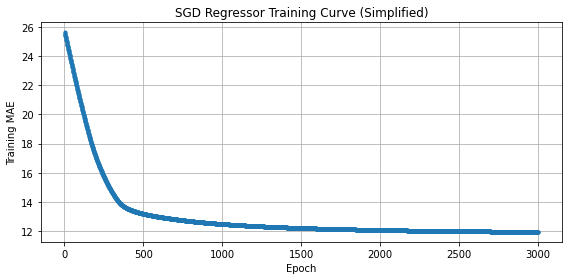

In [26]:
from sklearn.linear_model import SGDRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# Simple pipeline: preprocessing + SGDRegressor
sgd_pipeline = Pipeline([
    ('preprocessor', preprocessor2),  # use your existing preprocessor
    ('regressor', SGDRegressor(
        loss='huber',
        penalty='l2',
        alpha=1e-4,            # small, stable regularization
        learning_rate='adaptive',
        eta0=0.0001,            # small, stable learning rate
        max_iter=1,            # we’ll loop manually
        tol=None,
        random_state=42
    ))
])

# Prepare data
X_train, y_train = X, y  # you can use a subset if it's large

# Track loss manually
n_epochs = 3000
train_loss = []

for epoch in range(n_epochs):
    sgd_pipeline['regressor'].partial_fit(
        preprocessor2.fit_transform(X_train), y_train
    )
    y_pred = sgd_pipeline.predict(X_train)
    mae = mean_absolute_error(y_train, y_pred)
    train_loss.append(mae)
print(train_loss[-1])
# Plot the MAE over epochs
plt.figure(figsize=(8, 4))
plt.plot(range(1, n_epochs + 1), train_loss, marker='o', markersize=3)
plt.title("SGD Regressor Training Curve (Simplified)")
plt.xlabel("Epoch")
plt.ylabel("Training MAE")
plt.grid(True)
plt.tight_layout()
plt.show()


### Autograder 

In the autograder you will need to provide two things: 1) estimate of the MAE of your model on unseen data, 2) the predictions on the autograder data. For the autograder data we only provide the features and not the regression targets. Thus, you cannot compute the MAE on this data yourself - you need to estimate that with the data provided above. 

In [7]:
data_autograder = pd.read_csv('health_insurance_autograde.csv')
data_autograder.head()
best_model = Pipeline([
    ('preprocessor', preprocessor2),
    ('regressor', RandomForestRegressor(
        random_state=42,
        n_estimators=100,
        criterion='absolute_error',
        min_samples_split=10,
        min_samples_leaf=15
    ))
])

# Fit on the full training data
best_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('poly',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['experience']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['kidslt6', 'kids618',
                                                   'husby']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['hhi', 'whi', 'hhi2',
                                                   'education', 'race',
                                                   'hispanic', 'region'])])),
                ('regressor',
                 RandomForestRegressor(criterion='absolute_error',
                                       min_samples_leaf=15,
                                       min_samples_split=10,
                                       random_state=42))])

In [8]:
# TODO Replace this with your own estimate of the MAE of your best model
estimate_MAE_on_new_data = 10.584

# TODO Replace this with the predictions of your best model
# via e.g. prediction = model.predict(data_autograder)
predictions_autograder_data = best_model.predict(data_autograder)

# Upload this file to the Vocareum autograder:
result = np.append(estimate_MAE_on_new_data, predictions_autograder_data)
pd.DataFrame(result).to_csv("autograder_submission.txt", index=False, header=False)